In [1]:


import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# -------------------------------
# 1. 기본 설정
# -------------------------------
base_dir = "./Data"
utm_epsg_uzb = 32641  # 우즈베키스탄 UTM 존
year = 2021  # 처리 대상 연도

# -------------------------------
# 2. 데이터 경로 설정
# -------------------------------
boundary_shp_path = "./Boundary_lines/uzb_grid_1km/uzb_boundary_grid_1km.shp"
input_rwi_path = "./uzb_relative_wealth_index.csv"  # RWI 원본 데이터 경로
output_dir = os.path.join(base_dir, str(year), "output")
os.makedirs(output_dir, exist_ok=True)

# -------------------------------
# 3. 공간 데이터 로드
# -------------------------------
# 1km 격자 경계 로드
grid_gdf = gpd.read_file(boundary_shp_path).to_crs(epsg=32641)
grid_gdf["grid_id"] = grid_gdf.index  # 고유 격자 ID 생성

# -------------------------------
# 4. RWI 데이터 처리
# -------------------------------
# CSV 데이터 로드 및 좌표계 변환
rwi_df = pd.read_csv(input_rwi_path)
rwi_gdf = gpd.GeoDataFrame(
    rwi_df,
    geometry=gpd.points_from_xy(rwi_df.longitude, rwi_df.latitude),
    crs="EPSG:4326"
).to_crs(epsg=utm_epsg_uzb)

# -------------------------------
# 5. 공간 조인 및 집계
# -------------------------------
# 격자와 RWI 포인트 조인
joined_rwi = gpd.sjoin(rwi_gdf, grid_gdf, how="left", predicate="intersects")

# 격자별 RWI 평균 계산
rwi_grid = joined_rwi.groupby("index_right")["rwi"].mean().reset_index()

# -------------------------------
# 6. 결과 병합 및 저장
# -------------------------------
result = grid_gdf.merge(
    rwi_grid,
    left_on="grid_id",
    right_on="index_right",
    how="left"
)

# 결측값 처리 (RWI 데이터 없는 격자는 0으로 설정)
result["rwi"] = result["rwi"].fillna(0)

# 최종 결과 저장
output_path = os.path.join(output_dir, f"uzb_{year}_rwi_1km_joined.geojson")
result.to_file(output_path, driver="GeoJSON")
print(f"✅ 처리 완료: {output_path}")


✅ 처리 완료: ./Data/2021/output/uzb_2021_rwi_1km_joined.geojson


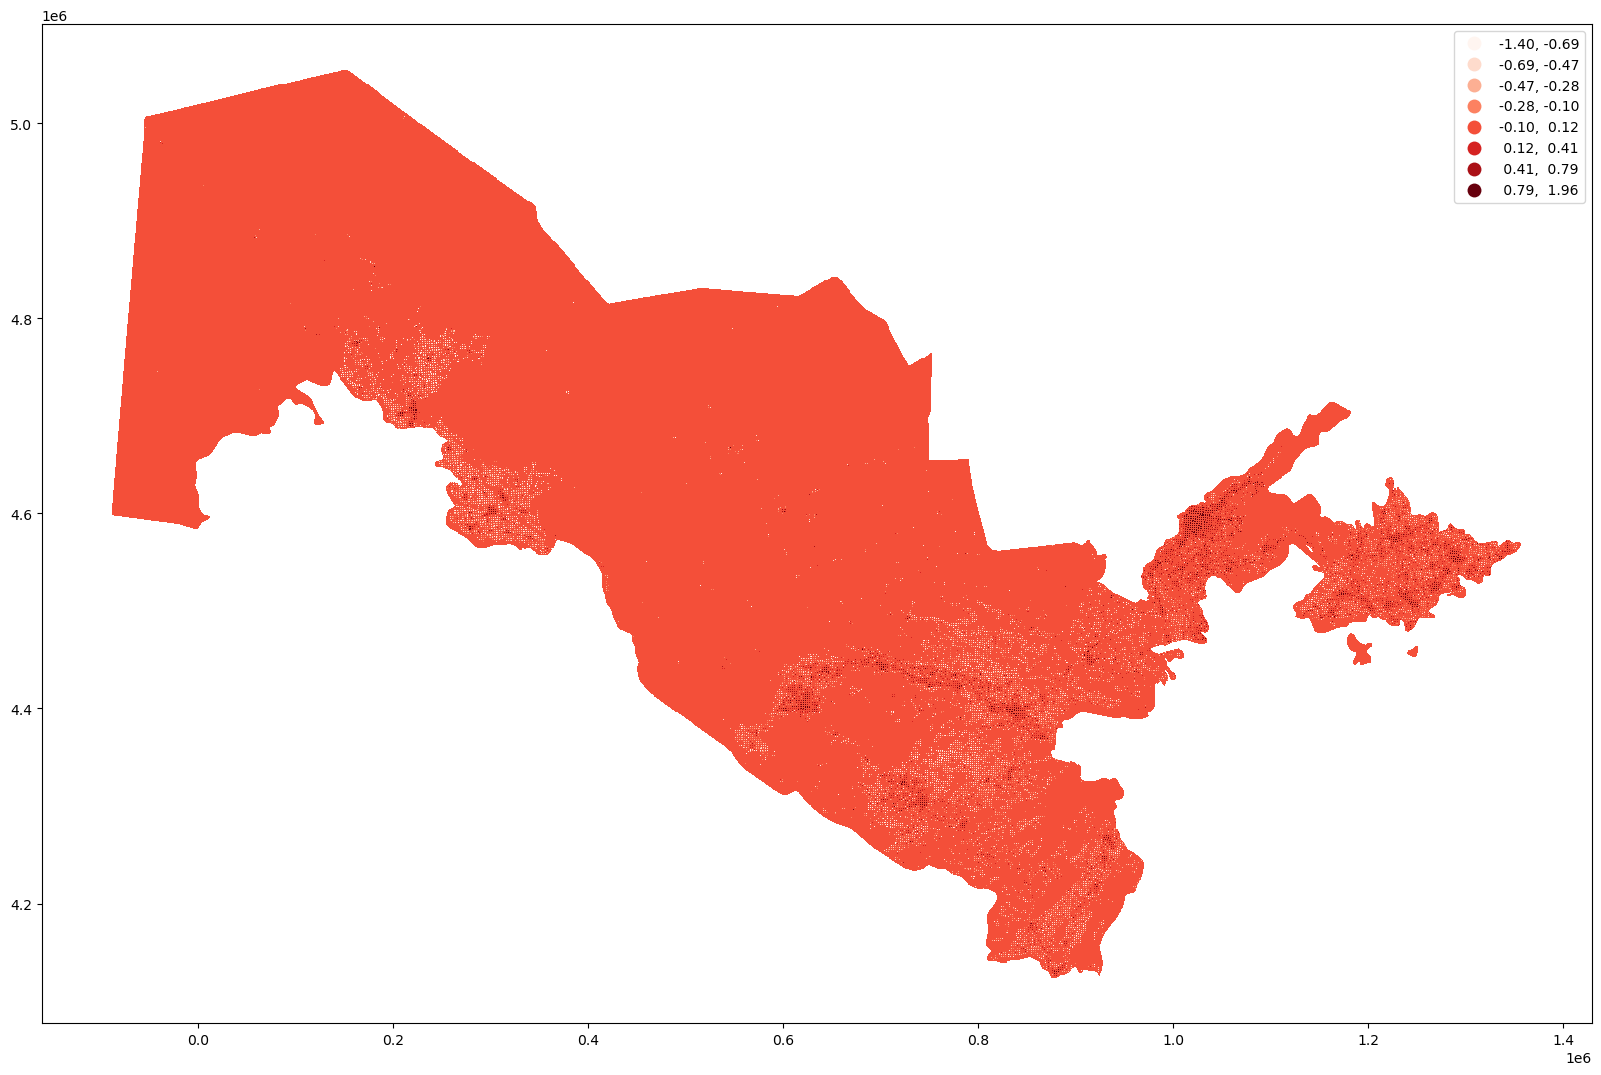

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
result_gdf = gpd.read_file('./Data/2021/output/uzb_2021_rwi_1km_joined.geojson')

fig, ax = plt.subplots(figsize=(20,17))
result_gdf.plot(column='rwi',
                ax=ax,
                legend=True,
                cmap='Reds',
                scheme='NaturalBreaks',
                k=8
                )
plt.show()

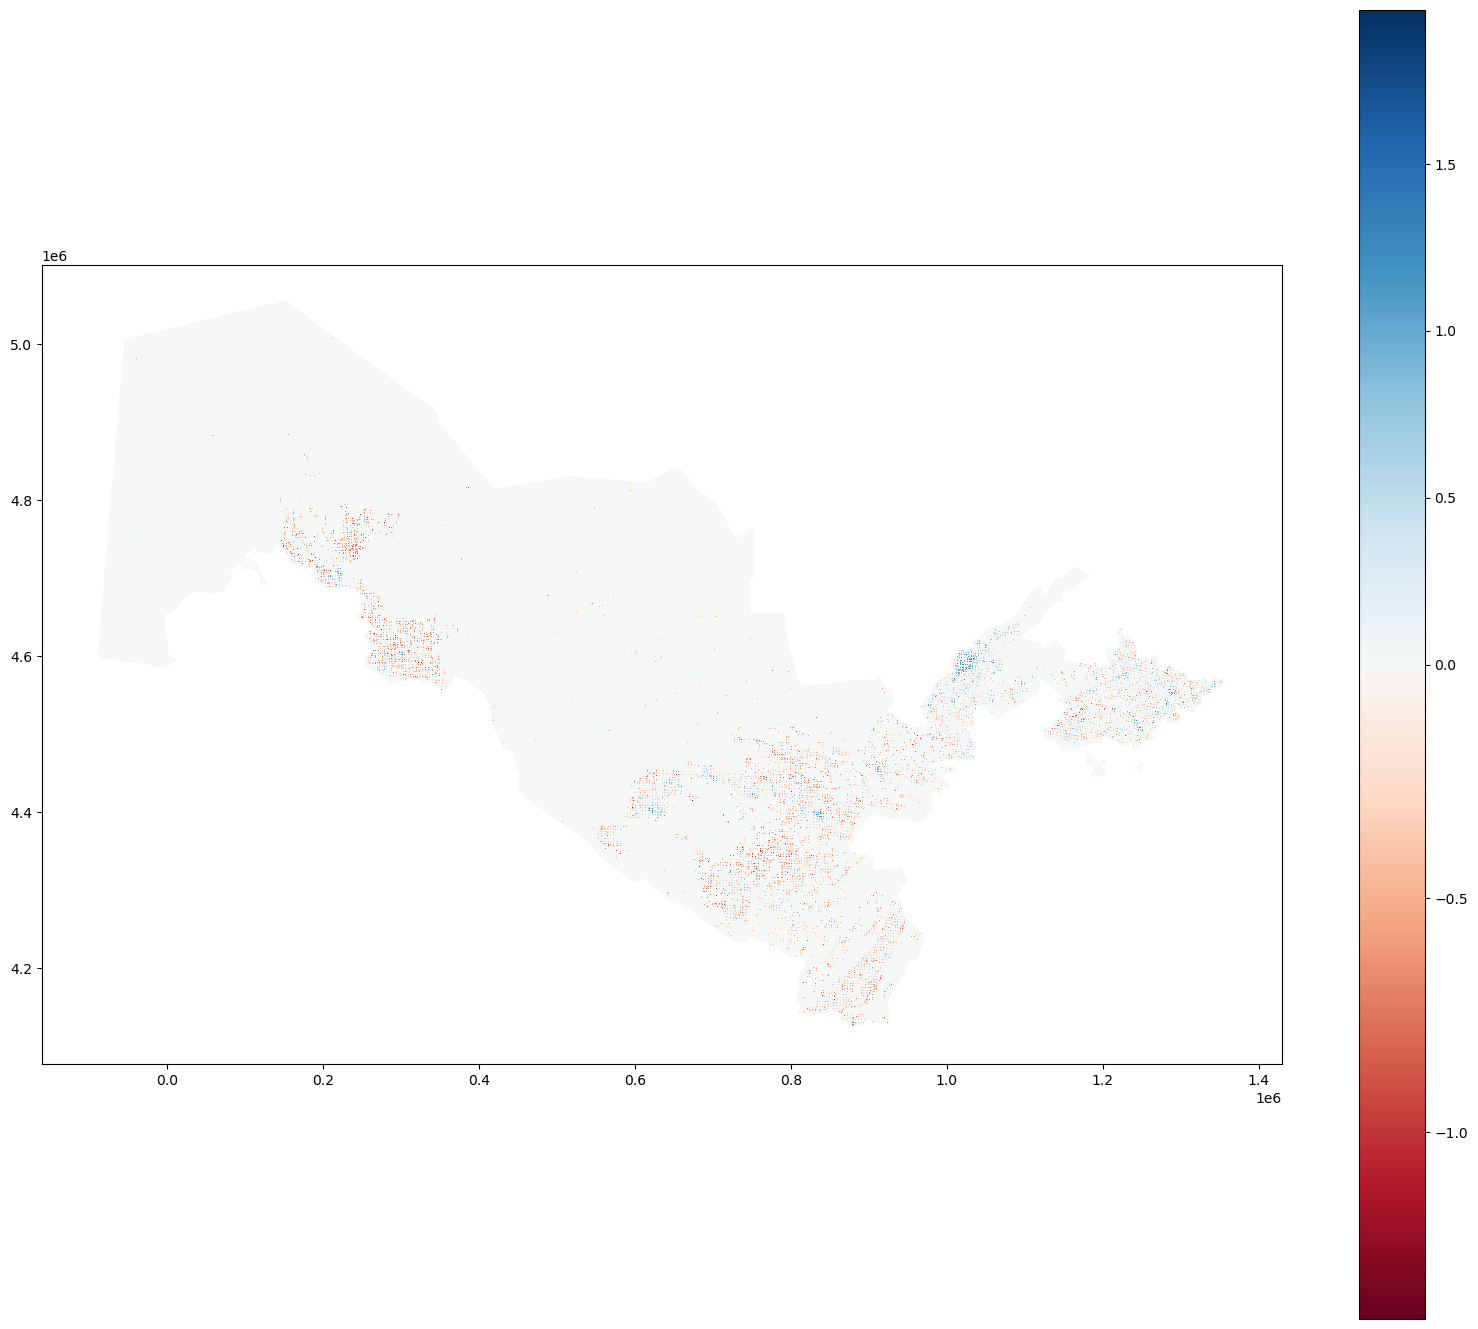

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

norm = TwoSlopeNorm(vmin=result_gdf['rwi'].min(), vcenter=0, vmax=result_gdf['rwi'].max())
fig, ax = plt.subplots(figsize=(20,17))
result_gdf.plot(
    column='rwi',
    cmap='RdBu',        # 또는 'seismic', 'bwr', 'coolwarm' 등
    norm=norm,
    legend=True,
    ax=ax
)
plt.show()